# TP 3 - Nettoyage et Feature Engineering
## Mastère 2 - Data & Intelligence Artificielle

**Durée** : 45 minutes

### Objectifs
1. Traiter les valeurs manquantes (stratégie médiane/mode)
2. Détecter et traiter les outliers (méthode IQR et capping)
3. Créer des features métier pertinentes :
   - TotalIncome
   - LoanAmountToIncome
   - EMI (mensualité)
   - EMIToIncome
   - Transformations logarithmiques
4. Encoder les variables catégorielles
5. Sauvegarder le dataset nettoyé

## 📦 Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuration
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Imports réussis")

✅ Imports réussis


## 📊 Chargement des données

In [2]:
# Charger le dataset
df = pd.read_csv('../data/loan_data.csv')

print("=" * 80)
print("DATASET INITIAL")
print("=" * 80)
print(f"Dimensions : {df.shape}")
print(f"\nValeurs manquantes :")
print(df.isnull().sum())

# Créer une copie pour le travail
df_clean = df.copy()

print("\n✅ Dataset chargé et copié")

DATASET INITIAL
Dimensions : (614, 13)

Valeurs manquantes :
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

✅ Dataset chargé et copié


In [3]:
# 🚨 IMPORTANT : Supprimer la colonne Loan_ID (identifiant sans pouvoir prédictif)
if 'Loan_ID' in df_clean.columns:
    print("\n⚠️ Colonne 'Loan_ID' détectée")
    print("   → C'est un identifiant unique sans pouvoir prédictif")
    print("   → L'inclure causerait du data leakage et un overfitting")
    df_clean = df_clean.drop('Loan_ID', axis=1)
    print("   ✅ Loan_ID supprimée")
    print(f"   Nouvelles dimensions : {df_clean.shape}")
else:
    print("\n✅ Pas de colonne Loan_ID détectée")


⚠️ Colonne 'Loan_ID' détectée
   → C'est un identifiant unique sans pouvoir prédictif
   → L'inclure causerait du data leakage et un overfitting
   ✅ Loan_ID supprimée
   Nouvelles dimensions : (614, 12)


---
## 🔧 ÉTAPE 1 : Traitement des valeurs manquantes

### Stratégie
- **Variables numériques** : Imputer avec la **médiane** (robuste aux outliers)
- **Variables catégorielles** : Imputer avec le **mode** (valeur la plus fréquente)

### Pourquoi la médiane plutôt que la moyenne ?
La médiane n'est pas influencée par les valeurs extrêmes. Par exemple, si les revenus sont [1000, 2000, 3000, 100000], la moyenne (26500) est tirée vers le haut par 100000, alors que la médiane (2500) est plus représentative.

In [4]:
print("\n" + "=" * 80)
print("ÉTAPE 1 : TRAITEMENT DES VALEURS MANQUANTES")
print("=" * 80)

# Définir les colonnes numériques et catégorielles
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 
                  'Loan_Amount_Term', 'Credit_History']
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 
                    'Self_Employed', 'Property_Area']


ÉTAPE 1 : TRAITEMENT DES VALEURS MANQUANTES


### Imputation des variables numériques

In [5]:
# TODO : Imputer les valeurs manquantes numériques avec la médiane
for col in numerical_cols:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        median_value = df_clean[col].median()
        missing_count = df_clean[col].isnull().sum()
        
        # Remplir les NaN avec la médiane
        df_clean[col].fillna(median_value, inplace=True)
        
        print(f"✅ {col}: {missing_count} NaN remplacés par la médiane ({median_value:.2f})")

✅ LoanAmount: 22 NaN remplacés par la médiane (128.00)
✅ Loan_Amount_Term: 14 NaN remplacés par la médiane (360.00)
✅ Credit_History: 50 NaN remplacés par la médiane (1.00)


### Imputation des variables catégorielles

In [6]:
# TODO : Imputer les valeurs manquantes catégorielles avec le mode
for col in categorical_cols:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        mode_value = df_clean[col].mode()[0]
        missing_count = df_clean[col].isnull().sum()
        
        # Remplir les NaN avec le mode
        df_clean[col].fillna(mode_value, inplace=True)
        
        print(f"✅ {col}: {missing_count} NaN remplacés par le mode ('{mode_value}')")

✅ Gender: 13 NaN remplacés par le mode ('Male')
✅ Married: 3 NaN remplacés par le mode ('Yes')
✅ Dependents: 15 NaN remplacés par le mode ('0')
✅ Self_Employed: 32 NaN remplacés par le mode ('No')


In [7]:
# Vérification finale
print(f"\n✅ Total de valeurs manquantes après imputation : {df_clean.isnull().sum().sum()}")


✅ Total de valeurs manquantes après imputation : 0


---
## 🎯 ÉTAPE 2 : Détection et traitement des outliers

### Qu'est-ce qu'un outlier ?
Une valeur **aberrante** qui s'écarte fortement des autres observations. Les outliers peuvent :
- Être des **erreurs de saisie** (revenu de 1 000 000 000€)
- Être des **valeurs réelles** mais extrêmes (PDG avec très haut salaire)
- **Fausser les modèles** ML sensibles aux valeurs extrêmes

### Méthode IQR (InterQuartile Range)
- **Q1** : Premier quartile (25% des données)
- **Q3** : Troisième quartile (75% des données)
- **IQR** : Q3 - Q1
- **Outliers** : Valeurs < Q1 - 1.5×IQR ou > Q3 + 1.5×IQR

### Notre approche : Capping
Au lieu de **supprimer** les outliers (perte d'information), nous allons les **plafonner** (capping) aux percentiles 1% et 99%.

### Visualisation des outliers AVANT traitement


ÉTAPE 2 : DÉTECTION ET TRAITEMENT DES OUTLIERS
📊 Graphique 'outliers_before.png' sauvegardé


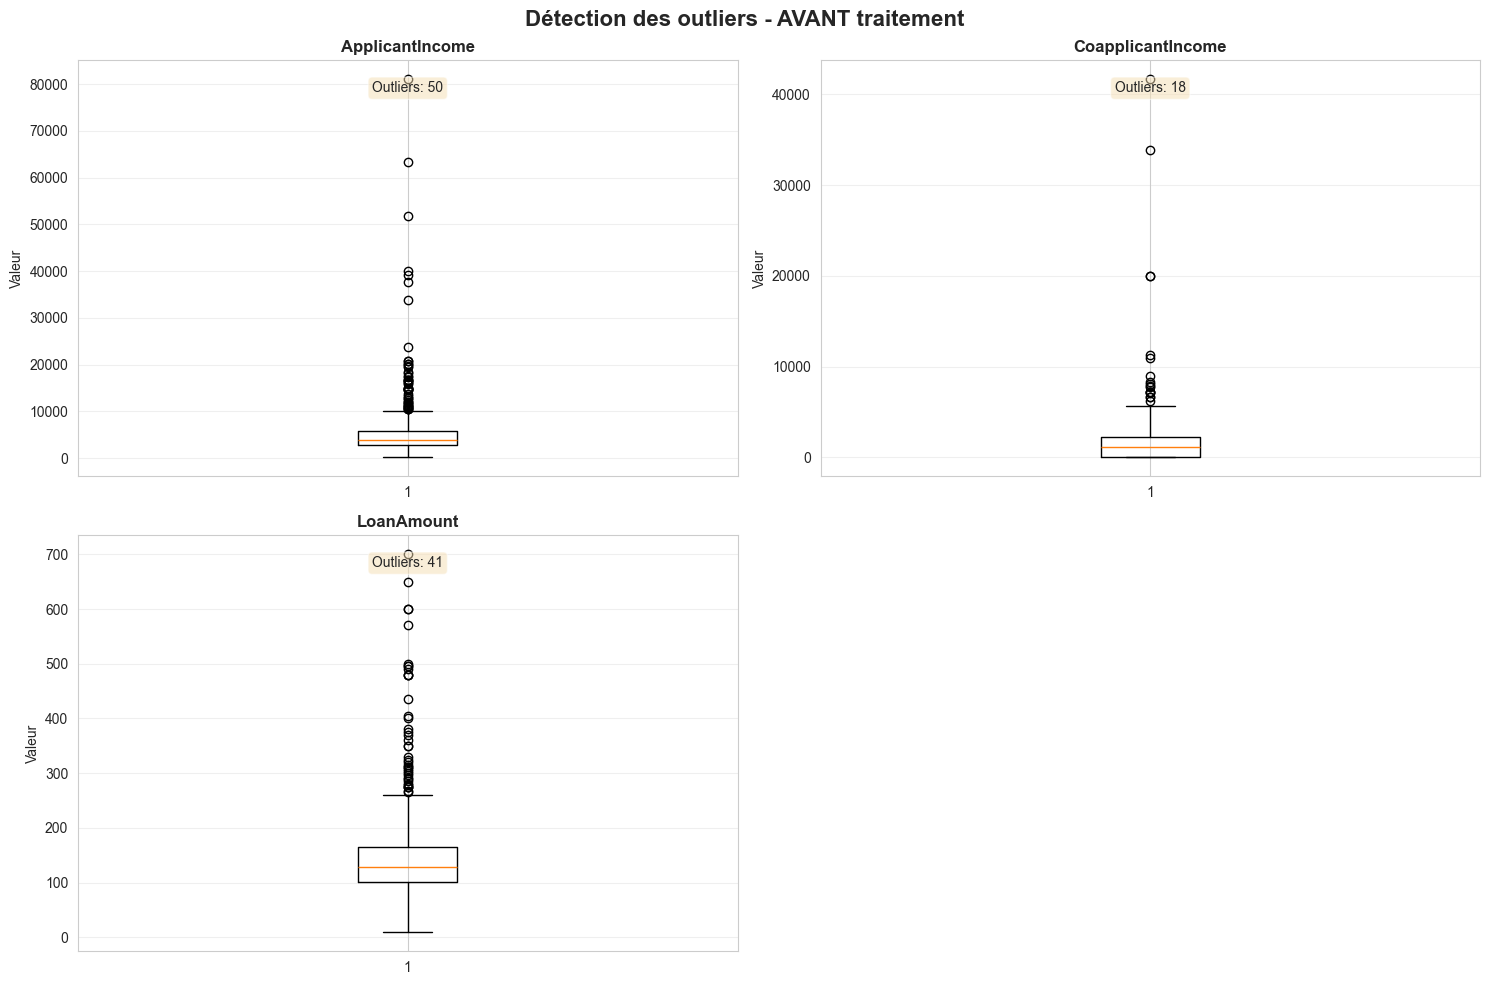

In [8]:
print("\n" + "=" * 80)
print("ÉTAPE 2 : DÉTECTION ET TRAITEMENT DES OUTLIERS")
print("=" * 80)

# Créer les boxplots pour visualiser les outliers
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Détection des outliers - AVANT traitement', fontsize=16, fontweight='bold')

outlier_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

for idx, col in enumerate(outlier_cols):
    row = idx // 2
    col_idx = idx % 2
    
    # Boxplot
    axes[row, col_idx].boxplot(df_clean[col].dropna(), vert=True)
    axes[row, col_idx].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[row, col_idx].set_ylabel('Valeur')
    axes[row, col_idx].grid(axis='y', alpha=0.3)
    
    # Calculer les statistiques d'outliers
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    n_outliers = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    axes[row, col_idx].text(0.5, 0.95, f'Outliers: {n_outliers}', 
                           transform=axes[row, col_idx].transAxes,
                           ha='center', va='top', fontsize=10,
                           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Supprimer le dernier subplot vide
fig.delaxes(axes[1, 1])

plt.tight_layout()
plt.savefig('outliers_before.png', dpi=300, bbox_inches='tight')
print("📊 Graphique 'outliers_before.png' sauvegardé")
plt.show()

### Fonction de capping (plafonnement)

In [9]:
# TODO : Implémenter la fonction de capping
def cap_outliers(df, column, lower_percentile=1, upper_percentile=99):
    """
    Plafonne les valeurs extrêmes en utilisant des percentiles
    
    Args:
        df: DataFrame
        column: Nom de la colonne
        lower_percentile: Percentile inférieur (défaut: 1%)
        upper_percentile: Percentile supérieur (défaut: 99%)
    
    Returns:
        DataFrame avec valeurs plafonnées
    """
    lower_bound = df[column].quantile(lower_percentile / 100)
    upper_bound = df[column].quantile(upper_percentile / 100)
    
    # Compter les valeurs plafonnées
    n_capped_lower = (df[column] < lower_bound).sum()
    n_capped_upper = (df[column] > upper_bound).sum()
    
    # Appliquer le capping
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    
    if n_capped_lower + n_capped_upper > 0:
        print(f"✅ {column}: {n_capped_lower} valeurs plafonnées en bas, "
              f"{n_capped_upper} en haut (percentiles {lower_percentile}-{upper_percentile})")
    
    return df

print("✅ Fonction cap_outliers créée")

✅ Fonction cap_outliers créée


### Application du capping

In [10]:
# Appliquer le capping sur les revenus
for col in ['ApplicantIncome', 'CoapplicantIncome']:
    df_clean = cap_outliers(df_clean, col, lower_percentile=1, upper_percentile=99)

# Pour LoanAmount, utiliser des percentiles plus conservateurs
df_clean = cap_outliers(df_clean, 'LoanAmount', lower_percentile=0, upper_percentile=95)

print("\n✅ Capping appliqué sur toutes les variables")

✅ ApplicantIncome: 6 valeurs plafonnées en bas, 7 en haut (percentiles 1-99)
✅ CoapplicantIncome: 0 valeurs plafonnées en bas, 7 en haut (percentiles 1-99)
✅ LoanAmount: 0 valeurs plafonnées en bas, 31 en haut (percentiles 0-95)

✅ Capping appliqué sur toutes les variables


---
## 🏗️ ÉTAPE 3 : Feature Engineering

Le **feature engineering** consiste à créer de nouvelles variables (features) à partir des variables existantes pour améliorer la performance du modèle.

### Pourquoi c'est important ?
Les modèles ML ne peuvent pas "deviner" les relations complexes. Par exemple :
- Le modèle voit `ApplicantIncome` et `LoanAmount` séparément
- Mais le **ratio** `LoanAmount / Income` est plus informatif (c'est le taux d'endettement !)

### Features que nous allons créer :
1. **TotalIncome** : Revenu du ménage (applicant + coapplicant)
2. **LoanAmountToIncome** : Ratio d'endettement
3. **EMI** : Mensualité estimée (Equated Monthly Installment)
4. **EMIToIncome** : Part du revenu consacrée au remboursement
5. **Log_LoanAmount** : Transformation log (réduit l'asymétrie)
6. **Log_TotalIncome** : Transformation log
7. **Has_Coapplicant** : Indicateur binaire

In [11]:
print("\n" + "=" * 80)
print("ÉTAPE 3 : FEATURE ENGINEERING")
print("=" * 80)


ÉTAPE 3 : FEATURE ENGINEERING


### Feature 1 : Revenu total du ménage

In [12]:
# TODO : Créer TotalIncome
df_clean['TotalIncome'] = df_clean['ApplicantIncome'] + df_clean['CoapplicantIncome']
print(f"✅ Feature créée : TotalIncome (moyenne: {df_clean['TotalIncome'].mean():.2f}€)")

✅ Feature créée : TotalIncome (moyenne: 6698.23€)


### Feature 2 : Ratio d'endettement

In [13]:
# TODO : Créer LoanAmountToIncome (éviter division par zéro)
df_clean['LoanAmountToIncome'] = df_clean['LoanAmount'] / (df_clean['TotalIncome'] + 1)
print(f"✅ Feature créée : LoanAmountToIncome (moyenne: {df_clean['LoanAmountToIncome'].mean():.3f})")

✅ Feature créée : LoanAmountToIncome (moyenne: 0.024)


### Feature 3 : EMI (Mensualité)

In [14]:
# TODO : Calculer la mensualité estimée
# Formule simplifiée : EMI = LoanAmount / Loan_Amount_Term
df_clean['EMI'] = df_clean['LoanAmount'] / df_clean['Loan_Amount_Term']
print(f"✅ Feature créée : EMI (moyenne: {df_clean['EMI'].mean():.2f}€/mois)")

✅ Feature créée : EMI (moyenne: 0.45€/mois)


### Feature 4 : Ratio EMI sur revenu

In [15]:
# TODO : Créer EMIToIncome
df_clean['EMIToIncome'] = df_clean['EMI'] / (df_clean['TotalIncome'] + 1)
print(f"✅ Feature créée : EMIToIncome (moyenne: {df_clean['EMIToIncome'].mean():.4f})")

✅ Feature créée : EMIToIncome (moyenne: 0.0001)


### Feature 5 & 6 : Transformations logarithmiques

**Pourquoi le logarithme ?**
- Réduit l'asymétrie des distributions (skewness)
- Ramène les grandes valeurs vers des échelles plus gérables
- Améliore souvent la performance des modèles linéaires

In [16]:
# TODO : Appliquer log sur les variables asymétriques
df_clean['Log_LoanAmount'] = np.log(df_clean['LoanAmount'] + 1)
df_clean['Log_TotalIncome'] = np.log(df_clean['TotalIncome'] + 1)

print(f"✅ Features créées : Log_LoanAmount, Log_TotalIncome")

✅ Features créées : Log_LoanAmount, Log_TotalIncome


### Feature 7 : Indicateur de co-demandeur

In [17]:
# TODO : Créer une variable binaire indiquant la présence d'un co-demandeur
df_clean['Has_Coapplicant'] = (df_clean['CoapplicantIncome'] > 0).astype(int)
print(f"✅ Feature créée : Has_Coapplicant "
      f"({df_clean['Has_Coapplicant'].sum()} personnes avec co-demandeur)")

✅ Feature créée : Has_Coapplicant (341 personnes avec co-demandeur)


### Visualisation des nouvelles features


📊 Graphique 'new_features.png' sauvegardé


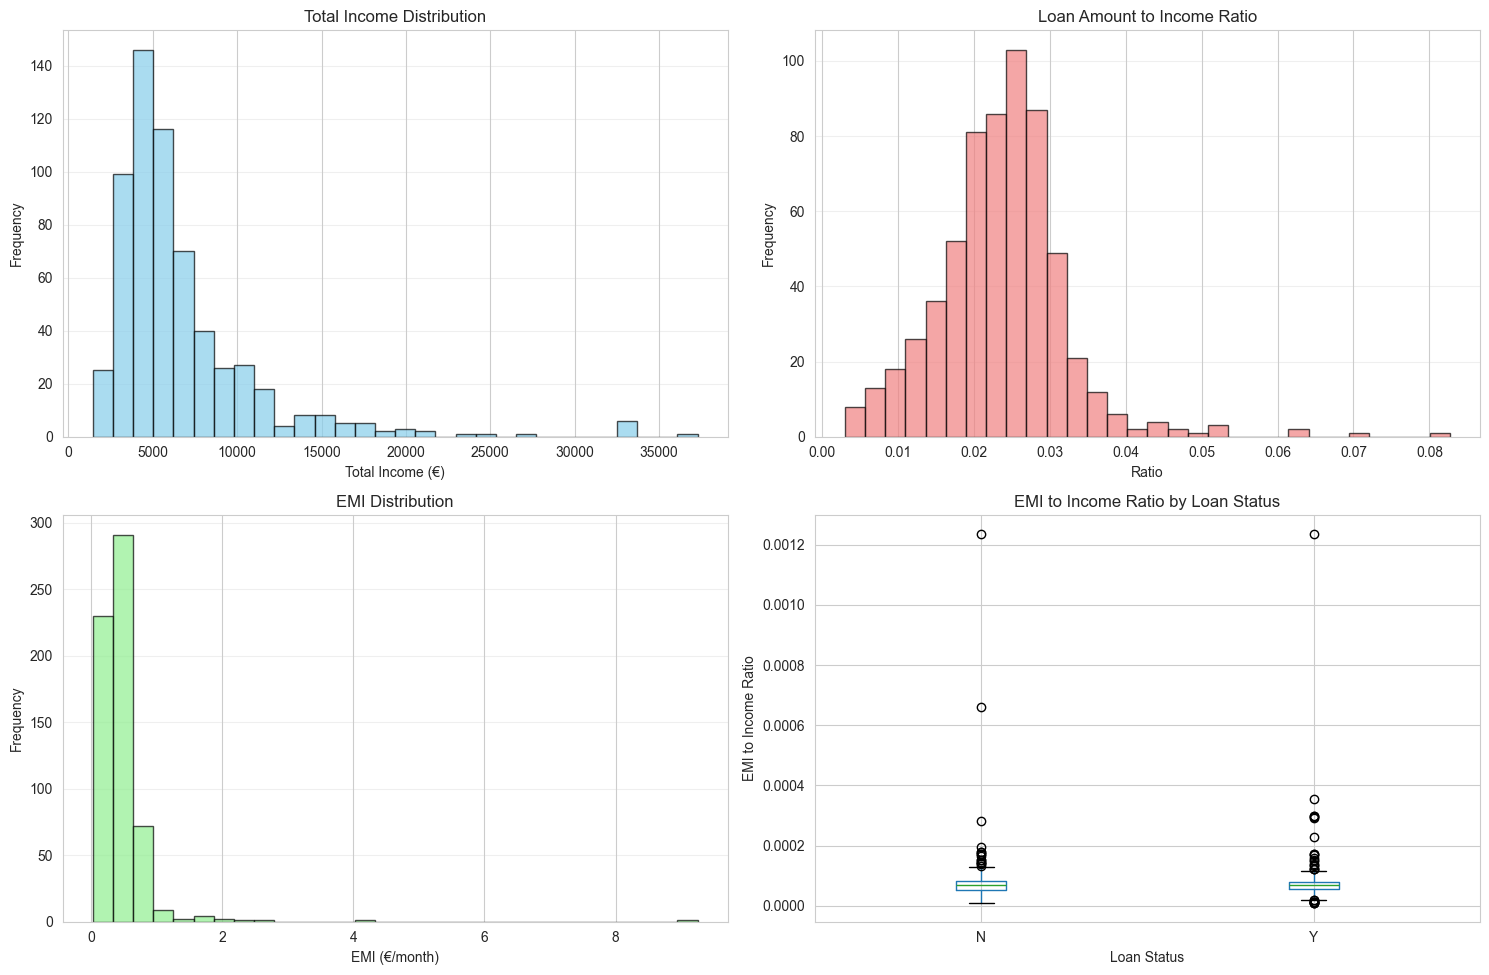

In [18]:
# Visualiser les nouvelles features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Nouvelles features créées', fontsize=16, fontweight='bold')

# Distribution TotalIncome
axes[0, 0].hist(df_clean['TotalIncome'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Total Income Distribution')
axes[0, 0].set_xlabel('Total Income (€)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(axis='y', alpha=0.3)

# Distribution LoanAmountToIncome
axes[0, 1].hist(df_clean['LoanAmountToIncome'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Loan Amount to Income Ratio')
axes[0, 1].set_xlabel('Ratio')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(axis='y', alpha=0.3)

# Distribution EMI
axes[1, 0].hist(df_clean['EMI'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('EMI Distribution')
axes[1, 0].set_xlabel('EMI (€/month)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(axis='y', alpha=0.3)

# EMIToIncome vs Loan_Status
if 'Loan_Status' in df_clean.columns:
    df_clean.boxplot(column='EMIToIncome', by='Loan_Status', ax=axes[1, 1])
    axes[1, 1].set_title('EMI to Income Ratio by Loan Status')
    axes[1, 1].set_xlabel('Loan Status')
    axes[1, 1].set_ylabel('EMI to Income Ratio')
    plt.suptitle('')  # Supprimer le titre automatique du boxplot

plt.tight_layout()
plt.savefig('new_features.png', dpi=300, bbox_inches='tight')
print("\n📊 Graphique 'new_features.png' sauvegardé")
plt.show()

---
## 🔤 ÉTAPE 4 : Encodage des variables catégorielles

Les modèles ML ne comprennent que les nombres. Il faut donc **encoder** les variables catégorielles.

### Deux méthodes :

#### 1. Label Encoding
- Pour variables **ordinales** (avec un ordre logique)
- Exemple : Education (Graduate > Not Graduate)
- Transforme en : 0, 1, 2...

#### 2. One-Hot Encoding
- Pour variables **nominales** (sans ordre)
- Exemple : Property_Area (Urban, Rural, Semiurban)
- Transforme en : colonnes binaires (Area_Urban, Area_Rural...)

**⚠️ Attention** : One-Hot avec `drop_first=True` évite la multicolinéarité (dummy variable trap)

In [19]:
print("\n" + "=" * 80)
print("ÉTAPE 4 : ENCODAGE DES VARIABLES CATÉGORIELLES")
print("=" * 80)


ÉTAPE 4 : ENCODAGE DES VARIABLES CATÉGORIELLES


### Label Encoding pour variables ordinales

In [20]:
# TODO : Encoder Education (Graduate = 1, Not Graduate = 0)
if 'Education' in df_clean.columns:
    df_clean['Education'] = df_clean['Education'].map({'Graduate': 1, 'Not Graduate': 0})
    print("✅ Education encodée : Graduate=1, Not Graduate=0")

# TODO : Encoder Loan_Status (Y = 1, N = 0)
if 'Loan_Status' in df_clean.columns:
    df_clean['Loan_Status'] = df_clean['Loan_Status'].map({'Y': 1, 'N': 0})
    print("✅ Loan_Status encodée : Y=1, N=0")

✅ Education encodée : Graduate=1, Not Graduate=0
✅ Loan_Status encodée : Y=1, N=0


### One-Hot Encoding pour variables nominales

In [21]:
# TODO : Encoder Property_Area (Dummy variables)
if 'Property_Area' in df_clean.columns:
    df_clean = pd.get_dummies(df_clean, columns=['Property_Area'], prefix='Area', drop_first=True)
    print("✅ Property_Area encodée (One-Hot) : Area_Semiurban, Area_Urban")

# TODO : Encoder Gender
if 'Gender' in df_clean.columns:
    df_clean = pd.get_dummies(df_clean, columns=['Gender'], prefix='Gender', drop_first=True)
    print("✅ Gender encodée (One-Hot) : Gender_Male")

# TODO : Encoder Married
if 'Married' in df_clean.columns:
    df_clean = pd.get_dummies(df_clean, columns=['Married'], prefix='Married', drop_first=True)
    print("✅ Married encodée (One-Hot) : Married_Yes")

# TODO : Encoder Self_Employed
if 'Self_Employed' in df_clean.columns:
    df_clean = pd.get_dummies(df_clean, columns=['Self_Employed'], prefix='SelfEmployed', drop_first=True)
    print("✅ Self_Employed encodée (One-Hot) : SelfEmployed_Yes")

# TODO : Encoder Dependents
if 'Dependents' in df_clean.columns:
    # Convertir '3+' en 3 pour traiter comme numérique
    df_clean['Dependents'] = df_clean['Dependents'].replace('3+', '3').astype(float)
    print("✅ Dependents convertie en numérique (3+ → 3)")

✅ Property_Area encodée (One-Hot) : Area_Semiurban, Area_Urban
✅ Gender encodée (One-Hot) : Gender_Male
✅ Married encodée (One-Hot) : Married_Yes
✅ Self_Employed encodée (One-Hot) : SelfEmployed_Yes
✅ Dependents convertie en numérique (3+ → 3)


---
## ✅ ÉTAPE 5 : Vérifications finales

In [22]:
print("\n" + "=" * 80)
print("ÉTAPE 5 : VÉRIFICATIONS FINALES")
print("=" * 80)

# Vérifier qu'il n'y a plus de NaN
print(f"\n✅ Valeurs manquantes restantes : {df_clean.isnull().sum().sum()}")


ÉTAPE 5 : VÉRIFICATIONS FINALES

✅ Valeurs manquantes restantes : 0


In [23]:
# Vérifier les types de données
print(f"\n✅ Types de données après nettoyage :")
df_clean.dtypes


✅ Types de données après nettoyage :


Dependents            float64
Education               int64
ApplicantIncome       float64
CoapplicantIncome     float64
LoanAmount            float64
Loan_Amount_Term      float64
Credit_History        float64
Loan_Status             int64
TotalIncome           float64
LoanAmountToIncome    float64
EMI                   float64
EMIToIncome           float64
Log_LoanAmount        float64
Log_TotalIncome       float64
Has_Coapplicant         int64
Area_Semiurban           bool
Area_Urban               bool
Gender_Male              bool
Married_Yes              bool
SelfEmployed_Yes         bool
dtype: object

In [24]:
# Afficher les dimensions finales
print(f"\n✅ Dimensions finales : {df_clean.shape}")
print(f"   → {df_clean.shape[0]} lignes")
print(f"   → {df_clean.shape[1]} colonnes (vs {df.shape[1]} initialement)")


✅ Dimensions finales : (614, 20)
   → 614 lignes
   → 20 colonnes (vs 13 initialement)


In [25]:
# Afficher les premières lignes
print(f"\n✅ Aperçu du dataset nettoyé :")
df_clean.head()


✅ Aperçu du dataset nettoyé :


,Dependents,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,LoanAmountToIncome,EMI,EMIToIncome,Log_LoanAmount,Log_TotalIncome,Has_Coapplicant,Area_Semiurban,Area_Urban,Gender_Male,Married_Yes,SelfEmployed_Yes
0,0.0,1,5849.0,0.0,128.0,360.0,1.0,1,5849.0,0.021880,0.355556,0.000061,4.859812,8.674197,0,False,True,True,False,False
1,1.0,1,4583.0,1508.0,128.0,360.0,1.0,0,6091.0,0.021011,0.355556,0.000058,4.859812,8.714732,1,False,False,True,True,False
2,0.0,1,3000.0,0.0,66.0,360.0,1.0,1,3000.0,0.021993,0.183333,0.000061,4.204693,8.006701,0,False,True,True,True,True
3,0.0,0,2583.0,2358.0,120.0,360.0,1.0,1,4941.0,0.024282,0.333333,0.000067,4.795791,8.505525,1,False,True,True,True,False
4,0.0,1,6000.0,0.0,141.0,360.0,1.0,1,6000.0,0.023496,0.391667,0.000065,4.955827,8.699681,0,False,True,True,False,False


In [26]:
# Statistiques descriptives
print(f"\n✅ Statistiques descriptives :")
df_clean.describe()


✅ Statistiques descriptives :


,Dependents,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,LoanAmountToIncome,EMI,EMIToIncome,Log_LoanAmount,Log_TotalIncome,Has_Coapplicant
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.744300,0.781759,5214.577964,1483.654967,139.251466,342.410423,0.855049,0.687296,6698.232932,0.023615,0.453053,0.000077,4.849423,8.659592,0.555375
std,1.009623,0.413389,4528.770082,1831.226927,60.283308,64.428629,0.352339,0.463973,4605.528246,0.008490,0.470433,0.000079,0.452289,0.511944,0.497329
min,0.000000,0.000000,1025.000000,0.000000,9.000000,12.000000,0.000000,0.000000,1442.000000,0.003016,0.025000,0.000008,2.302585,7.274480,0.000000
25%,0.000000,1.000000,2877.500000,0.000000,100.250000,360.000000,1.000000,0.000000,4166.000000,0.019028,0.288889,0.000055,4.617584,8.334952,0.000000
50%,0.000000,1.000000,3812.500000,1188.500000,128.000000,360.000000,1.000000,1.000000,5416.500000,0.023982,0.361111,0.000068,4.859812,8.597390,1.000000
75%,1.000000,1.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000,1.000000,7521.750000,0.027974,0.505556,0.000081,5.110477,8.925682,1.000000
max,3.000000,1.000000,32540.410000,8895.890000,293.400000,480.000000,1.000000,1.000000,37290.410000,0.082685,9.250000,0.001237,5.684939,10.526518,1.000000


---
## 💾 ÉTAPE 6 : Sauvegarde du dataset nettoyé

In [27]:
print("\n" + "=" * 80)
print("ÉTAPE 6 : SAUVEGARDE DU DATASET NETTOYÉ")
print("=" * 80)

# TODO : Sauvegarder le dataset nettoyé
output_file = '../data/processed/loan_data_clean.csv'
df_clean.to_csv(output_file, index=False)

print(f"\n✅ Dataset nettoyé sauvegardé dans '{output_file}'")
print(f"   Prêt pour l'étape de modélisation !")


ÉTAPE 6 : SAUVEGARDE DU DATASET NETTOYÉ

✅ Dataset nettoyé sauvegardé dans '../data/processed/loan_data_clean.csv'
   Prêt pour l'étape de modélisation !


---
## 📊 Récapitulatif du nettoyage

In [28]:
print("\n" + "=" * 80)
print("📊 RÉCAPITULATIF DU NETTOYAGE")
print("=" * 80)

print(f"""
✅ Valeurs manquantes traitées : {df.isnull().sum().sum()} → 0
✅ Outliers traités : Capping appliqué sur revenus et montants
✅ Features créées : 
   - TotalIncome
   - LoanAmountToIncome
   - EMI
   - EMIToIncome
   - Log_LoanAmount
   - Log_TotalIncome
   - Has_Coapplicant
✅ Encodage effectué :
   - Label Encoding : Education, Loan_Status
   - One-Hot Encoding : Property_Area, Gender, Married, Self_Employed
   - Conversion numérique : Dependents
✅ Dataset final : {df_clean.shape[0]} lignes × {df_clean.shape[1]} colonnes

Le dataset est maintenant prêt pour l'entraînement du modèle ! 🚀
""")

print("=" * 80)


📊 RÉCAPITULATIF DU NETTOYAGE

✅ Valeurs manquantes traitées : 149 → 0
✅ Outliers traités : Capping appliqué sur revenus et montants
✅ Features créées : 
   - TotalIncome
   - LoanAmountToIncome
   - EMI
   - EMIToIncome
   - Log_LoanAmount
   - Log_TotalIncome
   - Has_Coapplicant
✅ Encodage effectué :
   - Label Encoding : Education, Loan_Status
   - One-Hot Encoding : Property_Area, Gender, Married, Self_Employed
   - Conversion numérique : Dependents
✅ Dataset final : 614 lignes × 20 colonnes

Le dataset est maintenant prêt pour l'entraînement du modèle ! 🚀



---
## 🎯 Conclusion du TP

### Ce que vous avez appris
✅ Traiter les valeurs manquantes avec des stratégies appropriées  
✅ Détecter et traiter les outliers avec la méthode IQR  
✅ Créer des features métier pertinentes (feature engineering)  
✅ Encoder les variables catégorielles (Label + One-Hot)  
✅ Préparer un dataset propre pour le machine learning  

### Prochaines étapes
Dans le **TP 4**, nous allons :
- Entraîner un modèle de classification (Régression Logistique)
- Évaluer la performance avec plusieurs métriques
- Créer des visualisations (matrice de confusion, courbe ROC)
- Identifier les features les plus importantes

### Points clés à retenir
1. **Toujours vérifier les NaN** avant de modéliser
2. **Outliers ≠ Erreurs** : parfois ce sont des valeurs réelles
3. **Feature engineering > Algorithmes complexes** : de bonnes features font la différence
4. **Encoder intelligemment** : ordinale vs nominale